# **1. Perkenalan Dataset**


1. **Sumber Dataset**: Dataset diperoleh dari Kaggle (sumber orisinal: UCI Machine Learning Repository - *Predict Student Dropout and Academic Success*).
2. **Konteks**: Dataset ini memuat data demografi, status sosial-ekonomi, dan performa akademik mahasiswa.
3. **Tujuan**: Membangun model klasifikasi *machine learning* untuk memprediksi tingkat risiko mahasiswa, terbagi dalam kelas *Dropout*, *Enrolled*, atau *Graduate*.

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [2]:
file_path = '../dataset_raw/student_dropout.csv' 

try:
    df = pd.read_csv(file_path, sep=';')
    print("STATUS: Dataset berhasil dimuat, BOS.")
    display(df.head())
except FileNotFoundError:
    print(f"ERROR: File tidak ditemukan di {file_path}. Periksa kembali struktur folder!")

STATUS: Dataset berhasil dimuat, BOS.


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


# **4. Exploratory Data Analysis (EDA)**

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

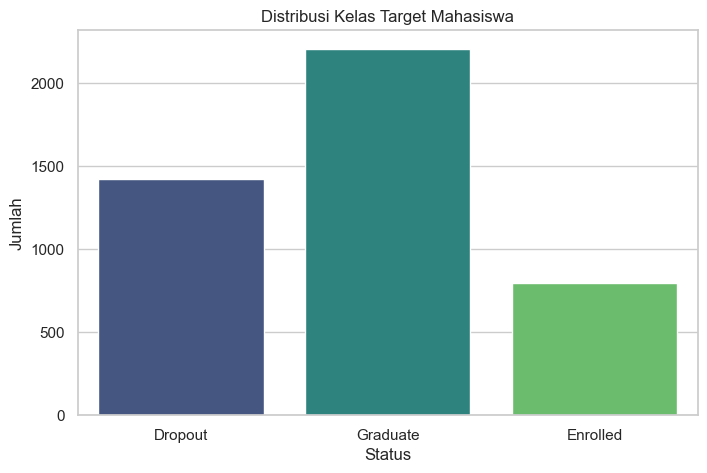


--- Pengecekan Missing Values ---
Series([], dtype: int64)


In [3]:
print("--- Informasi Dataset ---")
df.info()

print("\n--- Distribusi Target ---")
target_counts = df['Target'].value_counts()
print(target_counts)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Target', palette='viridis')
plt.title('Distribusi Kelas Target Mahasiswa')
plt.xlabel('Status')
plt.ylabel('Jumlah')
plt.show()

print("\n--- Pengecekan Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

# **5. Data Preprocessing**

In [4]:
df.drop_duplicates(inplace=True)

le = LabelEncoder()
df['Target'] = le.fit_transform(df['Target'])
print("Mapping Target:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['Target'])
y = df['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.15, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print("\n--- Dimensi Dataset Setelah Preprocessing & Splitting ---")
print(f"Total Data Train      : {X_train.shape[0]} baris")
print(f"Total Data Validation : {X_val.shape[0]} baris")
print(f"Total Data Test       : {X_test.shape[0]} baris")

X_train.to_csv('../dataset_preprocessing/X_train.csv', index=False)
X_val.to_csv('../dataset_preprocessing/X_val.csv', index=False)
X_test.to_csv('../dataset_preprocessing/X_test.csv', index=False)
y_train.to_csv('../dataset_preprocessing/y_train.csv', index=False)
y_val.to_csv('../dataset_preprocessing/y_val.csv', index=False)
y_test.to_csv('../dataset_preprocessing/y_test.csv', index=False)

print("\nSTATUS: Preprocessing selesai. Data bersih berhasil diekspor ke folder 'dataset_preprocessing'.")

Mapping Target: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

--- Dimensi Dataset Setelah Preprocessing & Splitting ---
Total Data Train      : 3098 baris
Total Data Validation : 662 baris
Total Data Test       : 664 baris

STATUS: Preprocessing selesai. Data bersih berhasil diekspor ke folder 'dataset_preprocessing'.
